# Декодирование сигналов Morse: Соревнование cryoarchive-incident
Этот ноутбук содержит решение для соревнования по декодированию искаженных сигналов азбуки Морзе.

In [ ]:

import json
import os
import sys
import zipfile
import random
import subprocess
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import matplotlib
import kagglehub
import kagglehub.cache
import kagglehub.handle

SEED = 42
MIN_EPOCHS = 15
EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 4e-4
WEIGHT_DECAY = 1e-4
TEST_SIZE = 0.2
DATASET_NAME = "cryoarchive-incident"
INTERACTIVE = True

# Colab budget controls. Current defaults keep the run close to the old 100-epoch budget.
USE_AUGMENTATION = True
USE_OPTUNA = True
OPTUNA_TRIALS = 10
OPTUNA_EPOCHS = 5
OPTUNA_TRAIN_FRACTION = 0.7
FINAL_TRAIN_ON_FULL_DATA = True
FINAL_EPOCHS = 10
NUM_WORKERS = 2

DEFAULT_MODEL_CONFIG = {
    "hidden_dim": 192,
    "cnn_channels": (64, 128, 192),
    "rnn_layers": 2,
    "dropout": 0.25,
}

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

if not INTERACTIVE:
    matplotlib.use("Agg")

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)



## 1. Загрузка и подготовка датасета

In [ ]:
handle = kagglehub.handle.parse_competition_handle(DATASET_NAME)
cache_path = Path(kagglehub.cache.get_cached_path(handle))
marker_path = Path(kagglehub.cache._get_competitions_completion_marker_filepath(handle))

if cache_path.exists() and marker_path.exists():
    path = cache_path
else:
    from kagglehub.auth import get_username
    username = get_username()
    if username is None:
        print("Вы не авторизованы в Kaggle. Запуск процесса авторизации...")
        kagglehub.login()
        username = get_username()
        if username is None:
            raise RuntimeError("Пожалуйста, введите ваш API-токен Kaggle в интерактивном окне выше и запустите эту ячейку снова.")
    print(f"Вы авторизованы как пользователь: {username}")
    path = kagglehub.competition_download(DATASET_NAME)

DATA_DIR = Path(path)
zip_file = DATA_DIR / "morse_dataset_public.zip"
extracted_dir = DATA_DIR / "morse_dataset_public"

if not extracted_dir.exists():
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

TRAIN_DIR = DATA_DIR / "morse_dataset_public" / "morse_dataset" / "train"
TEST_DIR = DATA_DIR / "morse_dataset_public" / "morse_dataset" / "test"
LABELS_CSV = TRAIN_DIR / "labels.csv"
SAMPLE_SUBMISSION_CSV = DATA_DIR / "sample_submission.csv"

## 2. Разведочный анализ данных (EDA)

(30000, 2)
    filename     text
0  00000.wav       83
1  00001.wav       68
2  00002.wav    41254
3  00003.wav     27-9
4  00004.wav  55-3991
Минимальная длина: 1
Максимальная длина: 9
Средняя длина: 4.54
Медианная длина: 5.00


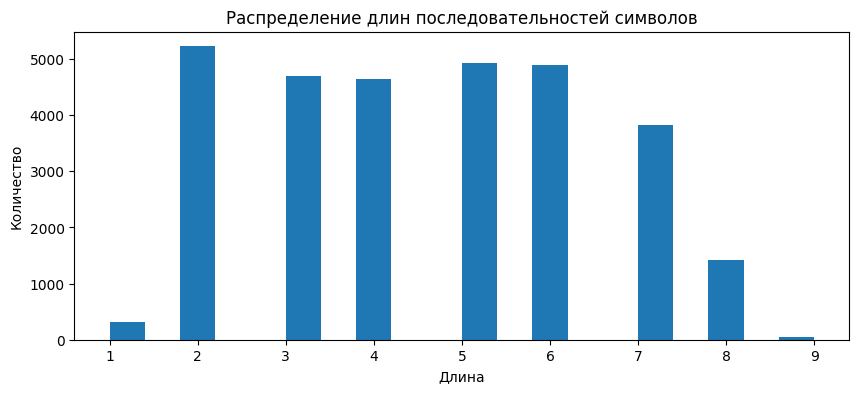

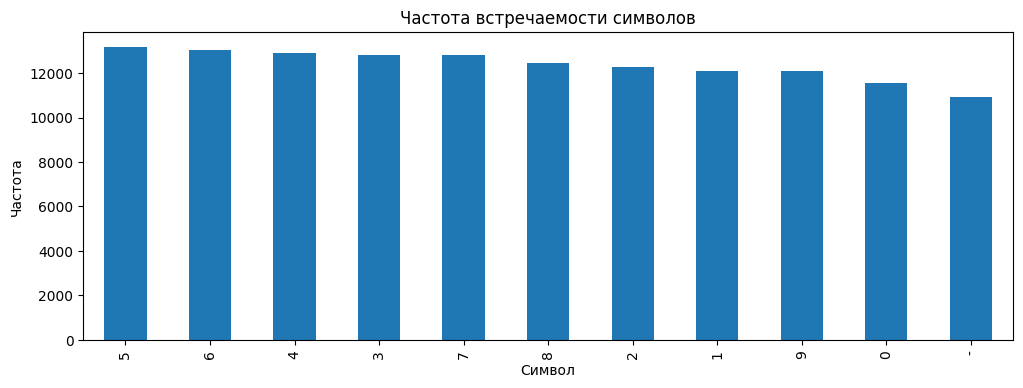

Частота дискретизации: 8000 Гц, Длина: 40000 отсчетов, Длительность: 5.00 сек
Уникальные частоты дискретизации: {8000}
Минимальная длительность: 5.00 сек, Максимальная: 5.00 сек
Минимальная RMS амплитуда: 4095.60, Максимальная: 4095.76


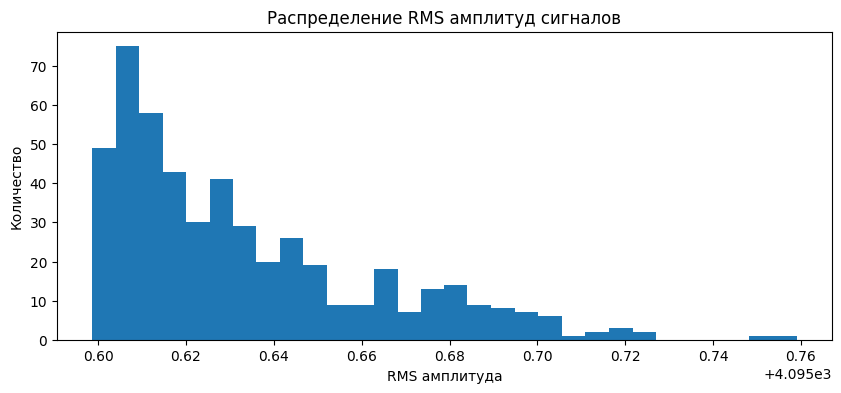

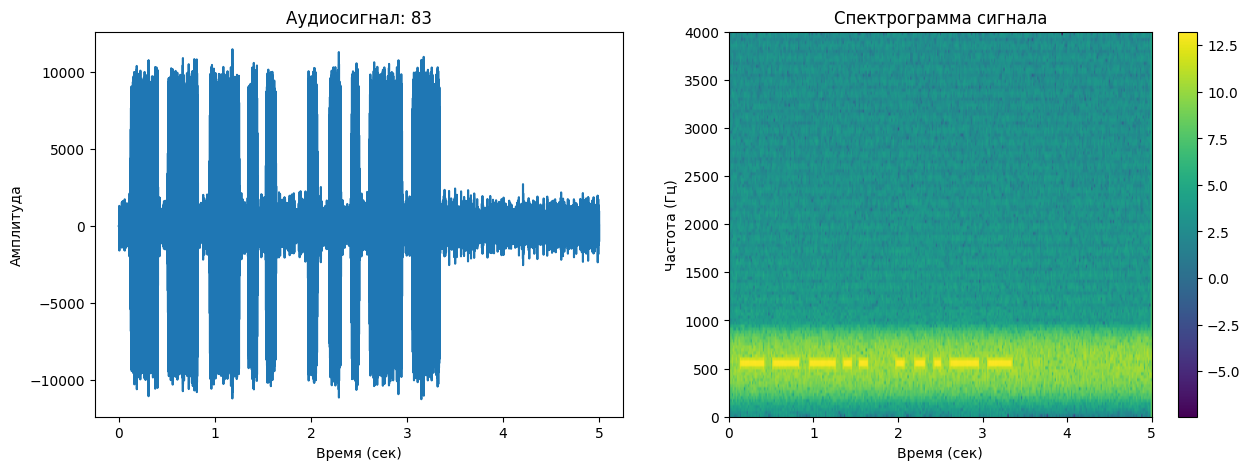

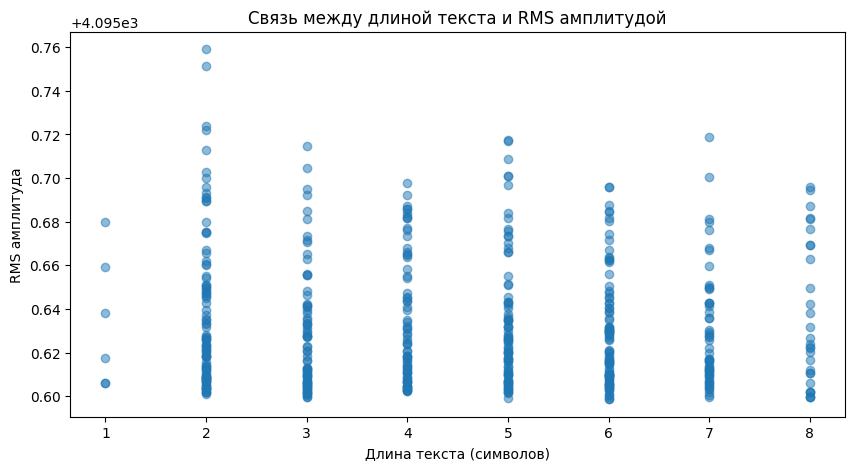

In [ ]:
df = pd.read_csv(LABELS_CSV)
print(df.shape)
print(df.head())

lengths = df["text"].astype(str).str.len()
print(f"Минимальная длина: {lengths.min()}")
print(f"Максимальная длина: {lengths.max()}")
print(f"Средняя длина: {lengths.mean():.2f}")
print(f"Медианная длина: {lengths.median():.2f}")

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=20)
plt.title("Распределение длин последовательностей символов")
plt.xlabel("Длина")
plt.ylabel("Количество")
plt.show()

all_chars = [char for text in df["text"].astype(str) for char in text]
char_counts = pd.Series(all_chars).value_counts()
plt.figure(figsize=(12, 4))
char_counts.plot(kind="bar")
plt.title("Частота встречаемости символов")
plt.xlabel("Символ")
plt.ylabel("Частота")
plt.show()

sample_filename = df.iloc[0]["filename"]
sample_wav = TRAIN_DIR / sample_filename
sr, y = wavfile.read(sample_wav)
print(f"Частота дискретизации: {sr} Гц, Длина: {len(y)} отсчетов, Длительность: {len(y)/sr:.2f} сек")

durations = []
rms_amplitudes = []
sample_rates = []
for idx in range(min(500, len(df))):
    wav_p = TRAIN_DIR / df.iloc[idx]["filename"]
    s_r, s_y = wavfile.read(wav_p)
    sample_rates.append(s_r)
    durations.append(len(s_y) / s_r)
    rms_amplitudes.append(np.sqrt(np.mean(s_y.astype(np.float32) ** 2)))

print(f"Уникальные частоты дискретизации: {set(sample_rates)}")
print(f"Минимальная длительность: {min(durations):.2f} сек, Максимальная: {max(durations):.2f} сек")
print(f"Минимальная RMS амплитуда: {min(rms_amplitudes):.2f}, Максимальная: {max(rms_amplitudes):.2f}")

plt.figure(figsize=(10, 4))
plt.hist(rms_amplitudes, bins=30)
plt.title("Распределение RMS амплитуд сигналов")
plt.xlabel("RMS амплитуда")
plt.ylabel("Количество")
plt.show()

y_tensor = torch.tensor(y, dtype=torch.float32)
window = torch.hann_window(256)
stft = torch.stft(y_tensor, n_fft=256, hop_length=128, win_length=256, window=window, return_complex=True)
spectrogram = torch.log(torch.abs(stft) + 1e-6).numpy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(np.linspace(0, len(y) / sr, len(y)), y)
axes[0].set_title(f"Аудиосигнал: {df.iloc[0]['text']}")
axes[0].set_xlabel("Время (сек)")
axes[0].set_ylabel("Амплитуда")

im = axes[1].imshow(spectrogram, aspect="auto", origin="lower", extent=[0, len(y)/sr, 0, sr/2])
axes[1].set_title("Спектрограмма сигнала")
axes[1].set_xlabel("Время (сек)")
axes[1].set_ylabel("Частота (Гц)")
plt.colorbar(im, ax=axes[1])
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(lengths[:500], rms_amplitudes, alpha=0.5)
plt.title("Связь между длиной текста и RMS амплитудой")
plt.xlabel("Длина текста (символов)")
plt.ylabel("RMS амплитуда")
plt.show()

## 3. Словарь символов и разделение выборки

In [ ]:
df = pd.read_csv(LABELS_CSV)
train_df, val_df = train_test_split(df, test_size=TEST_SIZE, random_state=SEED)

all_chars = set()
for text in df["text"].astype(str):
    all_chars.update(text)
unique_chars = sorted(list(all_chars))

char_to_idx = {char: idx for idx, char in enumerate(unique_chars, start=1)}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}
num_classes = len(char_to_idx) + 1

print(f"Размер обучающей выборки: {len(train_df)}")
print(f"Размер валидационной выборки: {len(val_df)}")
print(f"Уникальные символы в словаре ({len(unique_chars)}): {unique_chars}")

Размер обучающей выборки: 24000
Размер валидационной выборки: 6000
Уникальные символы в словаре (11): ['-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


## 4. Класс датасета и загрузчик данных

In [ ]:

class MorseDataset(Dataset):
    def __init__(self, dataframe, audio_dir, is_test=False, mean=None, std=None, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.filenames = self.df["filename"].values
        self.texts = self.df["text"].values if ("text" in self.df.columns and not is_test) else None
        self.mean = mean
        self.std = std
        self.augment = augment

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        wav_path = self.audio_dir / self.filenames[idx]
        sr, y = wavfile.read(wav_path)
        y = y.astype(np.float32)
        max_val = np.max(np.abs(y))
        if max_val > 0:
            y = y / max_val
        if self.augment:
            y = augment_waveform(y)
        y_tensor = torch.tensor(y, dtype=torch.float32)
        spectrogram = extract_features(y_tensor, self.mean, self.std)
        if self.augment:
            spectrogram = spec_augment(spectrogram)
        if self.texts is not None:
            text = self.texts[idx]
            label_indices = torch.tensor([char_to_idx[c] for c in str(text)], dtype=torch.long)
            return spectrogram.T, label_indices
        return spectrogram.T, self.filenames[idx]


def augment_waveform(y):
    y = y.copy()
    if random.random() < 0.7:
        y *= random.uniform(0.75, 1.25)
    if random.random() < 0.5:
        noise_std = random.uniform(0.002, 0.015)
        y += np.random.normal(0.0, noise_std, size=y.shape).astype(np.float32)
    if random.random() < 0.4 and len(y) > 64:
        shift = random.randint(-min(320, len(y) // 20), min(320, len(y) // 20))
        y = np.roll(y, shift)
    return np.clip(y, -1.0, 1.0)


def spec_augment(spec, max_freq_masks=2, max_time_masks=2, freq_mask_max=10, time_mask_frac=0.08):
    spec = spec.clone()
    n_freq, n_time = spec.shape
    fill_value = float(spec.mean())
    for _ in range(random.randint(0, max_freq_masks)):
        width = random.randint(1, min(freq_mask_max, n_freq))
        start = random.randint(0, max(0, n_freq - width))
        spec[start:start + width, :] = fill_value
    max_time = max(1, int(n_time * time_mask_frac))
    for _ in range(random.randint(0, max_time_masks)):
        width = random.randint(1, min(max_time, n_time))
        start = random.randint(0, max(0, n_time - width))
        spec[:, start:start + width] = fill_value
    return spec


def extract_features(y, mean=None, std=None):
    window = torch.hann_window(256, device=y.device)
    stft = torch.stft(y, n_fft=256, hop_length=128, win_length=256, window=window, return_complex=True)
    spectrogram = torch.log1p(torch.abs(stft))
    if mean is not None and std is not None:
        spectrogram = (spectrogram - mean) / (std + 1e-8)
    return spectrogram


def compute_train_stats(dataset):
    sum_spec = torch.zeros(129)
    sq_sum_spec = torch.zeros(129)
    total_frames = 0
    original_augment = getattr(dataset, "augment", False)
    dataset.augment = False
    for idx in tqdm(range(len(dataset)), desc="Вычисление статистик"):
        spec, _ = dataset[idx]
        sum_spec += spec.sum(dim=0)
        sq_sum_spec += (spec ** 2).sum(dim=0)
        total_frames += spec.size(0)
    dataset.augment = original_augment
    mean = (sum_spec / total_frames).unsqueeze(1)
    std = torch.sqrt(torch.clamp(sq_sum_spec / total_frames - mean.squeeze(1) ** 2, min=1e-8)).unsqueeze(1)
    return mean, std


def collate_fn(batch):
    features = [item[0] for item in batch]
    input_lengths = torch.tensor([f.size(0) for f in features], dtype=torch.long)
    features_padded = nn.utils.rnn.pad_sequence(features, batch_first=True)

    if len(batch[0]) > 1 and isinstance(batch[0][1], torch.Tensor):
        labels = [item[1] for item in batch]
        target_lengths = torch.tensor([len(label) for label in labels], dtype=torch.long)
        labels_padded = nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=0)
        return features_padded, labels_padded, input_lengths, target_lengths
    filenames = [item[1] for item in batch]
    return features_padded, filenames, input_lengths


def make_loader(dataset, batch_size=BATCH_SIZE, shuffle=False):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_fn,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker if NUM_WORKERS else None,
    )


train_dataset = MorseDataset(train_df, TRAIN_DIR, augment=USE_AUGMENTATION)
mean, std = compute_train_stats(train_dataset)
train_dataset.mean = mean
train_dataset.std = std
torch.save({"mean": mean, "std": std}, "spectrogram_stats.pth")

val_dataset = MorseDataset(val_df, TRAIN_DIR, mean=mean, std=std)

train_loader = make_loader(train_dataset, shuffle=True)
val_loader = make_loader(val_dataset, shuffle=False)

Вычисление статистик:   0%|          | 0/24000 [00:00<?, ?it/s]

## 5. Архитектура модели

In [ ]:

class ConvNormBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.SiLU(),
        )
        self.shortcut = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.block(x) + self.shortcut(x))


class CRNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, cnn_channels=(64, 128, 192), rnn_layers=2, dropout=0.25):
        super().__init__()
        channels = [input_dim, *cnn_channels]
        self.cnn = nn.Sequential(*[
            ConvNormBlock(channels[i], channels[i + 1], dropout)
            for i in range(len(channels) - 1)
        ])
        self.rnn = nn.GRU(
            cnn_channels[-1],
            hidden_dim,
            num_layers=rnn_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if rnn_layers > 1 else 0.0,
        )
        self.fc_dropout = nn.Dropout(dropout + 0.1)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.cnn(x)
        x = x.transpose(1, 2)
        x, _ = self.rnn(x)
        x = self.fc_dropout(x)
        return self.fc(x)


def build_model(config=None):
    cfg = dict(DEFAULT_MODEL_CONFIG)
    if config:
        cfg.update(config)
    return CRNNModel(input_dim=129, output_dim=num_classes, **cfg), cfg


def greedy_decode(output_probs):
    arg_maxes = torch.argmax(output_probs, dim=-1)
    decoded_sequences = []
    for seq in arg_maxes:
        decoded = []
        prev = -1
        for idx in seq:
            idx_val = idx.item()
            if idx_val != prev:
                if idx_val != 0:
                    decoded.append(idx_to_char[idx_val])
                prev = idx_val
        decoded_sequences.append("".join(decoded))
    return decoded_sequences


def levenshtein_distance(s1, s2):
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]


NEG_INF = -float("inf")


def log_sum_exp(*args):
    res = args[0]
    for val in args[1:]:
        res = np.logaddexp(res, val)
    return res


def ctc_beam_search_decode(output_probs, beam_width=20, blank=0, prune_threshold=1e-5):
    import collections
    probs_np = output_probs.detach().cpu().numpy()
    decoded_sequences = []
    for probs in probs_np:
        T, S = probs.shape
        log_probs = np.log(np.clip(probs, 1e-12, 1.0))
        beam = {(): (0.0, NEG_INF)}
        for t in range(T):
            next_beam = collections.defaultdict(lambda: (NEG_INF, NEG_INF))
            active_s = np.argsort(probs[t])[-3:].tolist()
            active_s = [s for s in active_s if probs[t, s] > prune_threshold]
            if blank not in active_s:
                active_s.append(blank)
            for s in active_s:
                p = log_probs[t, s]
                for prefix, (p_b, p_nb) in beam.items():
                    if s == blank:
                        n_p_b, n_p_nb = next_beam[prefix]
                        n_p_b = log_sum_exp(n_p_b, p_b + p, p_nb + p)
                        next_beam[prefix] = (n_p_b, n_p_nb)
                    else:
                        n_prefix = prefix + (s,)
                        n_p_b, n_p_nb = next_beam[n_prefix]
                        if prefix and prefix[-1] == s:
                            n_p_nb = log_sum_exp(n_p_nb, p_b + p)
                            o_p_b, o_p_nb = next_beam[prefix]
                            o_p_nb = log_sum_exp(o_p_nb, p_nb + p)
                            next_beam[prefix] = (o_p_b, o_p_nb)
                        else:
                            n_p_nb = log_sum_exp(n_p_nb, p_b + p, p_nb + p)
                        next_beam[n_prefix] = (n_p_b, n_p_nb)
            beam = dict(sorted(next_beam.items(), key=lambda x: log_sum_exp(*x[1]), reverse=True)[:beam_width])
        best_prefix = max(beam.keys(), key=lambda x: log_sum_exp(*beam[x]))
        decoded_sequences.append("".join([idx_to_char[i] for i in best_prefix]))
    return decoded_sequences


def save_checkpoint(model, config, path):
    torch.save({"model_state": model.state_dict(), "config": config}, path)


def load_model_from_checkpoint(path, device):
    checkpoint = torch.load(path, map_location=device)
    config = checkpoint.get("config", DEFAULT_MODEL_CONFIG)
    model, config = build_model(config)
    state = checkpoint.get("model_state", checkpoint)
    model.load_state_dict(state)
    return model.to(device), config

## 6. Обучение и валидация

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CTCLoss(blank=0, zero_infinity=True)


def train_one_epoch(model, loader, optimizer, scheduler=None, desc="Train"):
    model.train()
    running_loss = 0.0
    total_samples = 0
    for features, labels, input_lengths, target_lengths in tqdm(loader, desc=desc):
        features = features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(features)
        outputs_log_probs = torch.log_softmax(outputs, dim=-1).transpose(0, 1)
        loss = criterion(outputs_log_probs, labels, input_lengths, target_lengths)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item() * features.size(0)
        total_samples += features.size(0)
    return running_loss / max(1, total_samples)


def evaluate_model(model, loader, desc="Val", use_beam=False):
    model.eval()
    total_lev = 0.0
    total_chars = 0
    exact_matches = 0
    val_samples = 0
    decoder = ctc_beam_search_decode if use_beam else greedy_decode

    with torch.no_grad():
        for features, labels, input_lengths, target_lengths in tqdm(loader, desc=desc):
            features = features.to(device, non_blocking=True)
            outputs = model(features)
            outputs_probs = torch.softmax(outputs, dim=-1)
            decoded_preds = decoder(outputs_probs)

            for idx, pred in enumerate(decoded_preds):
                label_seq = labels[idx][:target_lengths[idx]].tolist()
                true_str = "".join([idx_to_char[i] for i in label_seq])
                lev = levenshtein_distance(pred, true_str)
                total_lev += lev
                total_chars += len(true_str)
                exact_matches += int(lev == 0)
                val_samples += 1

    return {
        "lev": total_lev / max(1, val_samples),
        "cer": total_lev / max(1, total_chars),
        "acc": exact_matches / max(1, val_samples),
    }


def fit_model(config, train_loader, val_loader=None, epochs=EPOCHS, min_epochs=MIN_EPOCHS, patience=10, checkpoint_path="best_crnn_model.pth"):
    model, resolved_config = build_model(config)
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=LEARNING_RATE,
        steps_per_epoch=len(train_loader),
        epochs=epochs,
        div_factor=5,
        final_div_factor=20,
    )
    best_lev = float("inf")
    patience_counter = 0
    history = []

    for epoch in range(epochs):
        epoch_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scheduler,
            desc=f"Epoch {epoch + 1}/{epochs} [Train]",
        )

        if val_loader is None:
            print(f"Epoch {epoch + 1}/{epochs} - Loss: {epoch_loss:.4f}")
            continue

        metrics = evaluate_model(model, val_loader, desc=f"Epoch {epoch + 1}/{epochs} [Val]")
        history.append({"loss": epoch_loss, **metrics})
        print(
            f"Epoch {epoch + 1}/{epochs} - Loss: {epoch_loss:.4f} "
            f"- Val Levenshtein: {metrics['lev']:.4f} - Val CER: {metrics['cer']:.4f} - Val Accuracy: {metrics['acc']:.4f}"
        )

        if metrics["lev"] < best_lev:
            best_lev = metrics["lev"]
            save_checkpoint(model, resolved_config, checkpoint_path)
            print("Сохранена лучшая модель")
            patience_counter = 0
        elif epoch + 1 >= min_epochs:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Ранняя остановка сработала на эпохе {epoch + 1}")
                break

    if val_loader is None:
        save_checkpoint(model, resolved_config, checkpoint_path)
        best_lev = None

    return model, resolved_config, history, best_lev


def install_optuna_if_needed():
    try:
        import optuna
        return optuna
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "optuna"])
        import optuna
        return optuna


OPTUNA_CONFIG_PATH = "optuna_best_config.json"

best_config = dict(DEFAULT_MODEL_CONFIG)

if Path(OPTUNA_CONFIG_PATH).exists():
    with open(OPTUNA_CONFIG_PATH) as f:
        saved = json.load(f)
    saved["cnn_channels"] = tuple(saved["cnn_channels"])
    best_config.update(saved)
    print(f"Загружена конфигурация из {OPTUNA_CONFIG_PATH}: {best_config}")
elif USE_OPTUNA:
    optuna = install_optuna_if_needed()
    trial_size = max(1, int(len(train_dataset) * OPTUNA_TRAIN_FRACTION))
    rng = np.random.default_rng(SEED)
    trial_indices = rng.choice(len(train_dataset), size=trial_size, replace=False)
    optuna_train_loader = make_loader(Subset(train_dataset, trial_indices), shuffle=True)

    channel_options = {
        "small": (48, 96, 160),
        "balanced": (64, 128, 192),
        "wide": (64, 128, 256),
    }

    def objective(trial):
        channels_key = trial.suggest_categorical("cnn_channels", list(channel_options.keys()))
        config = {
            "hidden_dim": trial.suggest_categorical("hidden_dim", [128, 192, 256]),
            "cnn_channels": channel_options[channels_key],
            "rnn_layers": trial.suggest_int("rnn_layers", 1, 2),
            "dropout": trial.suggest_float("dropout", 0.15, 0.35),
        }
        _, _, _, trial_lev = fit_model(
            config,
            optuna_train_loader,
            val_loader,
            epochs=OPTUNA_EPOCHS,
            min_epochs=OPTUNA_EPOCHS,
            patience=OPTUNA_EPOCHS,
            checkpoint_path=f"optuna_trial_{trial.number}.pth",
        )
        return trial_lev

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=OPTUNA_TRIALS)
    best_config.update(study.best_params)
    best_config["cnn_channels"] = channel_options[best_config["cnn_channels"]]
    print("Лучшая конфигурация Optuna:", best_config)
    with open(OPTUNA_CONFIG_PATH, "w") as f:
        json.dump({k: list(v) if isinstance(v, tuple) else v for k, v in best_config.items()}, f, indent=2)
    print(f"Конфигурация сохранена в {OPTUNA_CONFIG_PATH}")

model, best_config, history, best_lev = fit_model(
    best_config,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    min_epochs=MIN_EPOCHS,
    patience=10,
    checkpoint_path="best_crnn_model.pth",
)

[I 2026-06-03 14:52:04,248] A new study created in memory with name: no-name-7bfe6d07-b98f-46ca-a957-b1e2e3245353


Epoch 1/5 [Train]:   0%|          | 0/525 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1/5 - Loss: 20.0950 - Val Levenshtein: 4.5272 - Val CER: 1.0000 - Val Accuracy: 0.0000
Сохранена лучшая модель


Epoch 2/5 [Train]:   0%|          | 0/525 [00:00<?, ?it/s]

...

Epoch 97/100 [Val]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 97/100 - Loss: 0.6238 - Val Levenshtein: 0.4455 - Val CER: 0.0984 - Val Accuracy: 0.7930


Epoch 98/100 [Train]:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 98/100 [Val]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 98/100 - Loss: 0.6181 - Val Levenshtein: 0.4472 - Val CER: 0.0988 - Val Accuracy: 0.7912
Ранняя остановка сработала на эпохе 98


## 7. Качественная оценка модели

In [ ]:

model, loaded_config = load_model_from_checkpoint("best_crnn_model.pth", device)
model.eval()

true_strs = []
pred_strs = []
levs = []
true_lens = []
pred_lens = []

with torch.no_grad():
    for features, labels, input_lengths, target_lengths in val_loader:
        features = features.to(device)
        outputs = model(features)
        outputs_probs = torch.softmax(outputs, dim=-1)
        decoded_preds = ctc_beam_search_decode(outputs_probs)

        for idx, pred in enumerate(decoded_preds):
            label_seq = labels[idx][:target_lengths[idx]].tolist()
            true_str = "".join([idx_to_char[i] for i in label_seq])
            true_strs.append(true_str)
            pred_strs.append(pred)
            lev = levenshtein_distance(pred, true_str)
            levs.append(lev)
            true_lens.append(len(true_str))
            pred_lens.append(len(pred))

val_results = pd.DataFrame({
    "true": true_strs,
    "pred": pred_strs,
    "levenshtein": levs,
    "true_len": true_lens,
    "pred_len": pred_lens
})

In [ ]:
avg_lev = val_results["levenshtein"].mean()
total_chars = val_results["true_len"].sum()
total_lev = val_results["levenshtein"].sum()
cer = total_lev / max(1, total_chars)
accuracy = (val_results["levenshtein"] == 0).mean()

print(f"Среднее расстояние Левенштейна: {avg_lev:.4f}")
print(f"Character Error Rate (CER): {cer:.4f}")
print(f"Sequence Accuracy: {accuracy:.4f}")

In [ ]:
def get_length_group(l):
    if l <= 4:
        return "Короткие (1-4)"
    elif l <= 8:
        return "Средние (5-8)"
    else:
        return "Длинные (9+)"

val_results["group"] = val_results["true_len"].apply(get_length_group)
group_stats = val_results.groupby("group").agg(
    count=("levenshtein", "count"),
    mean_levenshtein=("levenshtein", "mean"),
    accuracy=("levenshtein", lambda x: (x == 0).mean())
)
print("\nМетрики по группам длин:")
print(group_stats)


Метрики по группам длин:
                count  mean_levenshtein  accuracy
group                                            
Длинные (9+)       14          1.785714  0.500000
Короткие (1-4)   2957          0.208319  0.859317
Средние (5-8)    3029          0.555959  0.767580


In [ ]:
print("\nТоп-10 худших предсказаний:")
val_results.sort_values(by="levenshtein", ascending=False).head(10)


Топ-10 худших предсказаний:


,true,pred,levenshtein,true_len,pred_len,group
3301,521415-54,9,9,9,1,Длинные (9+)
831,829-8757,,8,8,0,Средние (5-8)
1377,66544440,,8,8,0,Средние (5-8)
366,794628-8,37-5,7,8,4,Средние (5-8)
5979,06-8561,,7,7,0,Средние (5-8)
2305,7260616,,7,7,0,Средние (5-8)
1880,083-846,,7,7,0,Средние (5-8)
5053,8700877,,7,7,0,Средние (5-8)
829,9003836,7,7,7,1,Средние (5-8)
3785,24434778,4,7,8,1,Средние (5-8)


In [ ]:
def get_alignment_errors(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + 1)
    substitutions = []
    i, j = m, n
    while i > 0 or j > 0:
        if i > 0 and j > 0 and s1[i-1] == s2[j-1]:
            i -= 1
            j -= 1
        elif i > 0 and j > 0 and dp[i][j] == dp[i-1][j-1] + 1:
            substitutions.append((s1[i-1], s2[j-1]))
            i -= 1
            j -= 1
        elif i > 0 and (j == 0 or dp[i][j] == dp[i-1][j] + 1):
            i -= 1
        else:
            j -= 1
    return substitutions

all_subs = []
for _, row in val_results.iterrows():
    all_subs.extend(get_alignment_errors(row["true"], row["pred"]))

if all_subs:
    sub_counts = pd.Series(all_subs).value_counts()
    print("\nТоп-10 наиболее частых замен символов:")
    for (true_c, pred_c), count in sub_counts.head(10).items():
        print(f"Истинный: '{true_c}' -> Предсказанный: '{pred_c}' | Количество: {count}")


Топ-10 наиболее частых замен символов:
Истинный: '1' -> Предсказанный: '2' | Количество: 39
Истинный: '1' -> Предсказанный: '0' | Количество: 24
Истинный: '6' -> Предсказанный: '5' | Количество: 22
Истинный: '4' -> Предсказанный: '5' | Количество: 20
Истинный: '5' -> Предсказанный: '6' | Количество: 18
Истинный: '7' -> Предсказанный: '6' | Количество: 18
Истинный: '6' -> Предсказанный: '7' | Количество: 15
Истинный: '2' -> Предсказанный: '1' | Количество: 15
Истинный: '0' -> Предсказанный: '1' | Количество: 15
Истинный: '2' -> Предсказанный: '3' | Количество: 13


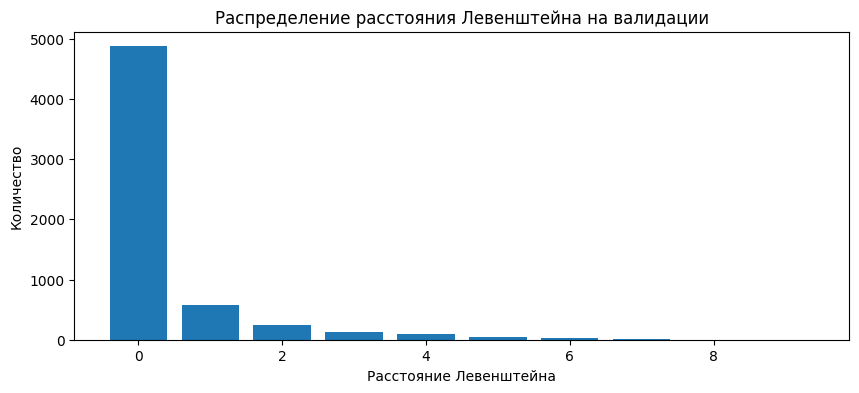

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(val_results["levenshtein"], bins=range(0, int(val_results["levenshtein"].max()) + 2), align="left", rwidth=0.8)
plt.title("Распределение расстояния Левенштейна на валидации")
plt.xlabel("Расстояние Левенштейна")
plt.ylabel("Количество")
plt.show()

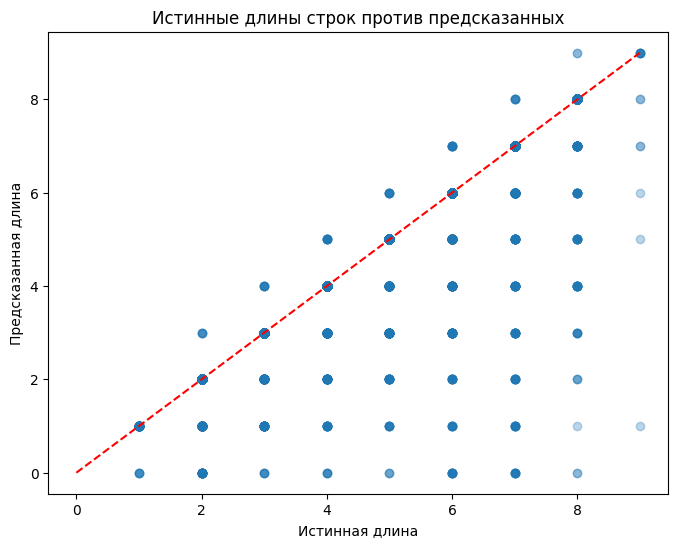

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(val_results["true_len"], val_results["pred_len"], alpha=0.3)
plt.plot([0, val_results["true_len"].max()], [0, val_results["true_len"].max()], "r--")
plt.title("Истинные длины строк против предсказанных")
plt.xlabel("Истинная длина")
plt.ylabel("Предсказанная длина")
plt.show()

## 8. Инференс на тестовой выборке и генерация сабмишна

## 8. Финальное обучение на всём датасете
После выбора архитектуры и проверки на валидации модель коротко дообучается на всех размеченных данных перед генерацией submission.

In [ ]:

if FINAL_TRAIN_ON_FULL_DATA:
    full_train_dataset = MorseDataset(df, TRAIN_DIR, augment=USE_AUGMENTATION)
    full_mean, full_std = compute_train_stats(full_train_dataset)
    full_train_dataset.mean = full_mean
    full_train_dataset.std = full_std
    torch.save({"mean": full_mean, "std": full_std}, "spectrogram_stats.pth")
    full_train_loader = make_loader(full_train_dataset, shuffle=True)

    print(f"Финальное обучение на всех {len(full_train_dataset)} примерах: {FINAL_EPOCHS} эпох")
    final_model, final_config, _, _ = fit_model(
        best_config,
        full_train_loader,
        val_loader=None,
        epochs=FINAL_EPOCHS,
        min_epochs=FINAL_EPOCHS,
        patience=FINAL_EPOCHS,
        checkpoint_path="final_crnn_model.pth",
    )
    MODEL_PATH_FOR_SUBMISSION = "final_crnn_model.pth"
else:
    MODEL_PATH_FOR_SUBMISSION = "best_crnn_model.pth"

Вычисление статистик:   0%|          | 0/30000 [00:00<?, ?it/s]

Финальное обучение на всех 30000 примерах: 10 эпох


Epoch 1/10 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 5.9396


Epoch 2/10 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 8/10 - Loss: 2.8398


Epoch 9/10 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 2.8236


Epoch 10/10 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 2.8169


In [34]:

test_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)
stats = torch.load("spectrogram_stats.pth", map_location="cpu")
test_dataset = MorseDataset(test_df, TEST_DIR, is_test=True, mean=stats["mean"], std=stats["std"])
test_loader = make_loader(test_dataset, shuffle=False)

MODEL_PATH_FOR_SUBMISSION = globals().get(
    "MODEL_PATH_FOR_SUBMISSION",
    "final_crnn_model.pth" if Path("final_crnn_model.pth").exists() else "best_crnn_model.pth",
)
model, submission_config = load_model_from_checkpoint(MODEL_PATH_FOR_SUBMISSION, device)
model.eval()
print(f"Submission будет сгенерирован из {MODEL_PATH_FOR_SUBMISSION}")

predictions = []
filenames_list = []

with torch.no_grad():
    for features, filenames, input_lengths in tqdm(test_loader, desc="Inference"):
        features = features.to(device)
        outputs = model(features)
        outputs_probs = torch.softmax(outputs, dim=-1)
        decoded_preds = ctc_beam_search_decode(outputs_probs)
        predictions.extend(decoded_preds)
        filenames_list.extend(filenames)

submission = pd.DataFrame({
    "filename": filenames_list,
    "text": predictions
})
submission.to_csv("submission.csv", index=False)
print("Файл submission.csv успешно сохранен.")

Submission будет сгенерирован из final_crnn_model.pth


Inference:   0%|          | 0/157 [00:00<?, ?it/s]

Файл submission.csv успешно сохранен.


## 9. Проверка сабмишна

In [35]:
sub = pd.read_csv("submission.csv", keep_default_na=False)
print(f"Формат сабмишна: {sub.shape}")
print(sub.head())
print(f"Есть ли пропущенные значения: {sub.isnull().any().any()}")

Формат сабмишна: (5000, 2)
    filename text
0  00000.wav     
1  00001.wav     
2  00002.wav     
3  00003.wav     
4  00004.wav     
Есть ли пропущенные значения: False
